Pipeline

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [ ]:
users = pd.read_csv("/content/users.csv", parse_dates=["signup_date"])
plans = pd.read_csv("/content/plans.csv")
subscriptions = pd.read_csv("/content/subscriptions.csv",
                            parse_dates=["start_date", "end_date", "cancel_date"])
payments = pd.read_csv("/content/payments.csv", parse_dates=["payment_date"])
usage = pd.read_csv("/content/usage_daily.csv")
usage['usage_date'] = pd.to_datetime(usage['usage_date'], format='%d-%m-%Y')
campaigns = pd.read_csv("/content/campaign_touchpoints.csv",
                        parse_dates=["touch_date"])

In [ ]:

users.drop_duplicates(subset=["user_id"], inplace=True)
subscriptions.drop_duplicates(inplace=True)
payments.drop_duplicates(inplace=True)


users["city_tier"] = users["city_tier"]
plans["plan_name"] = plans["plan_name"]
payments["payment_status"] = payments["payment_status"]


users["city_tier"].fillna("unknown", inplace=True)
usage.fillna(0, inplace=True)

usage["is_outlier"] = usage["minutes_used"] > usage["minutes_used"].quantile(0.99)

In [ ]:
import os

output_dir = '../data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

as_of_date = pd.to_datetime(usage["usage_date"].max())
users["tenure_days"] = (as_of_date - users["signup_date"]).dt.days
paid_payments = payments[payments["payment_status"] == "success"]
lifetime_paid = paid_payments.groupby("user_id").size().reset_index(name="lifetime_paid_months")

last_active = usage.groupby("user_id")["usage_date"].max().reset_index()
last_active.rename(columns={"usage_date": "last_active_date"}, inplace=True)

recent_4w = usage[usage["usage_date"] >= as_of_date - timedelta(weeks=4)]
engagement = recent_4w.groupby("user_id")["minutes_used"].sum().reset_index()

q1 = engagement["minutes_used"].quantile(0.33)
q2 = engagement["minutes_used"].quantile(0.66)

def engagement_band(x):
    if x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    else:
        return "high"

engagement["engagement_band"] = engagement["minutes_used"].apply(engagement_band)

dim_users = users.merge(lifetime_paid, on="user_id", how="left") \
                 .merge(last_active, on="user_id", how="left") \
                 .merge(engagement[["user_id", "engagement_band"]], on="user_id", how="left")

dim_users.fillna({"lifetime_paid_months":0, "engagement_band":"low"}, inplace=True)

dim_users.to_csv("../data/dim_users_enriched.csv", index=False)

In [ ]:
import os

output_dir = '../data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

usage["week_start"] = usage["usage_date"] - pd.to_timedelta(usage["usage_date"].dt.weekday, unit='d')

weekly_usage = usage.groupby(["user_id", "week_start"]).agg(
    active_days_week=("usage_date", "nunique"),
    total_minutes_week=("minutes_used", "sum"),
    sessions_week=("sessions_count", "sum")
).reset_index()

weekly_payments = payments.groupby(["user_id",
                                    payments["payment_date"].dt.to_period("W").apply(lambda r: r.start_time)]
                                   ).agg(
    payment_attempts_week=("payment_status", "count"),
    payment_failures_week=("payment_status", lambda x: (x=="failed").sum())
).reset_index()

weekly_payments.columns = ["user_id","week_start",
                           "payment_attempts_week","payment_failures_week"]

fact_weekly = weekly_usage.merge(weekly_payments,
                                  on=["user_id","week_start"], how="left")

fact_weekly.fillna(0, inplace=True)
fact_weekly.to_csv("../data/fact_user_weekly.csv", index=False)

In [ ]:
import os

output_dir = '../data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

window_start = as_of_date - timedelta(weeks=4)
model_window = fact_weekly[fact_weekly["week_start"] >= window_start]

agg_features = model_window.groupby("user_id").agg(
    active_days_4w=("active_days_week","sum"),
    total_minutes_4w=("total_minutes_week","sum"),
    sessions_4w=("sessions_week","sum"),
    payment_failures_4w=("payment_failures_week","sum")
).reset_index()


last_week = model_window.groupby("user_id").tail(1)
avg_prev = model_window.groupby("user_id")["active_days_week"].mean().reset_index()

trend = last_week.merge(avg_prev, on="user_id")
trend["usage_trend"] = trend["active_days_week_x"] - trend["active_days_week_y"]
trend = trend[["user_id","usage_trend"]]

model_data = agg_features.merge(trend, on="user_id", how="left") \
                         .merge(dim_users, on="user_id", how="left")


model_data["days_since_last_activity"] = (as_of_date - model_data["last_active_date"]).dt.days

future_cutoff = as_of_date + timedelta(days=14)

subscriptions["will_churn_14d"] = np.where(
    (subscriptions["cancel_date"].notna()) &
    (subscriptions["cancel_date"] <= future_cutoff),
    1, 0
)

churn_label = subscriptions.groupby("user_id")["will_churn_14d"].max().reset_index()

model_data = model_data.merge(churn_label, on="user_id", how="left")
model_data["will_churn_14d"].fillna(0, inplace=True)

model_data["as_of_date"] = as_of_date

model_data.to_csv("../data/model_churn_dataset.csv", index=False)

In [ ]:
features = [
    "active_days_4w",
    "total_minutes_4w",
    "sessions_4w",
    "payment_failures_4w",
    "usage_trend",
    "days_since_last_activity",
    "tenure_days",
    "lifetime_paid_months"
]

X = model_data[features]
y = model_data["will_churn_14d"]

split_index = int(len(model_data)*0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict_proba(X_test_scaled)[:,1]
print("Logistic ROC-AUC:", roc_auc_score(y_test, log_preds))


rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict_proba(X_test)[:,1]
print("RandomForest ROC-AUC:", roc_auc_score(y_test, rf_preds))

threshold = 0.4
rf_binary = (rf_preds >= threshold).astype(int)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_binary))
print("\nClassification Report:\n", classification_report(y_test, rf_binary))

importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop Churn Drivers:\n", importance.head(10))

print("\nPipeline Completed Successfully.")

Logistic ROC-AUC: 0.9197289972899729
RandomForest ROC-AUC: 0.9088482384823848

Confusion Matrix:
 [[362  48]
 [ 26  64]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.91       410
           1       0.57      0.71      0.63        90

    accuracy                           0.85       500
   macro avg       0.75      0.80      0.77       500
weighted avg       0.87      0.85      0.86       500


Top Churn Drivers:
                     feature  importance
1          total_minutes_4w    0.382021
2               sessions_4w    0.299207
6               tenure_days    0.289300
4               usage_trend    0.014748
0            active_days_4w    0.010772
7      lifetime_paid_months    0.003462
5  days_since_last_activity    0.000489
3       payment_failures_4w    0.000000

Pipeline Completed Successfully.


Analysis

In [ ]:
users["cohort_month"] = users["signup_date"].dt.to_period("M").astype(str)
subscriptions["active_month"] = subscriptions["start_date"].dt.to_period("M").astype(str)

cohort_data = pd.merge(users, subscriptions, on="user_id", how="inner")

cohort_data["cohort_year"] = pd.to_datetime(cohort_data["cohort_month"]).dt.year
cohort_data["cohort_period"] = pd.to_datetime(cohort_data["cohort_month"]).dt.to_period("M")
cohort_data["active_period"] = pd.to_datetime(cohort_data["active_month"]).dt.to_period("M")
cohort_data["retention_month_num"] = (cohort_data["active_period"] - cohort_data["cohort_period"]).apply(lambda x: x.n)

retained_users = cohort_data.groupby(["cohort_month", "retention_month_num"])[['user_id']].nunique().reset_index()
retained_users.rename(columns={'user_id': 'retained_users'}, inplace=True)

cohort_size = retained_users[retained_users["retention_month_num"] == 0][["cohort_month", "retained_users"]]
cohort_size.rename(columns={'retained_users': 'cohort_size'}, inplace=True)

cohort_retention = pd.merge(retained_users, cohort_size, on="cohort_month", how="left")
cohort_retention["retention_rate"] = (cohort_retention["retained_users"] / cohort_retention["cohort_size"]) * 100

retention_pivot = cohort_retention.pivot_table(index="cohort_month",
                                               columns="retention_month_num",
                                               values="retention_rate").fillna(0)

print("Cohort Retention Pivot Table:")
print(retention_pivot.head())


Cohort Retention Pivot Table:
retention_month_num      0          1
cohort_month                         
2025-05              100.0  21.100917
2025-06              100.0   6.810036
2025-07              100.0  12.671233
2025-08              100.0  16.044776
2025-09              100.0  10.526316


In [ ]:
features = [
    "active_days_4w",
    "total_minutes_4w",
    "sessions_4w",
    "payment_failures_4w",
    "usage_trend",
    "days_since_last_activity",
    "tenure_days",
    "lifetime_paid_months"
]

X = model_data[features]
y = model_data["will_churn_14d"]

split_index = int(len(model_data)*0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict_proba(X_test_scaled)[:,1]
print("Logistic ROC-AUC:", roc_auc_score(y_test, log_preds))


rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict_proba(X_test)[:,1]
print("RandomForest ROC-AUC:", roc_auc_score(y_test, rf_preds))

threshold = 0.4
rf_binary_predictions = (rf_preds >= threshold).astype(int)

print("\nConfusion Matrix (with threshold 0.4):\n", confusion_matrix(y_test, rf_binary_predictions))
print("\nClassification Report (with threshold 0.4):\n", classification_report(y_test, rf_binary_predictions))


Logistic ROC-AUC: 0.9197289972899729
RandomForest ROC-AUC: 0.9088482384823848

Confusion Matrix (with threshold 0.4):
 [[362  48]
 [ 26  64]]

Classification Report (with threshold 0.4):
               precision    recall  f1-score   support

           0       0.93      0.88      0.91       410
           1       0.57      0.71      0.63        90

    accuracy                           0.85       500
   macro avg       0.75      0.80      0.77       500
weighted avg       0.87      0.85      0.86       500



In [ ]:
import pandas as pd

users = pd.read_csv("/content/users.csv", parse_dates=["signup_date"])
subscriptions = pd.read_csv("/content/subscriptions.csv",
                            parse_dates=["start_date", "end_date", "cancel_date"])

users.drop_duplicates(subset=["user_id"], inplace=True)
subscriptions.drop_duplicates(inplace=True)

users["cohort_month"] = users["signup_date"].dt.to_period("M").astype(str)
subscriptions["active_month"] = subscriptions["start_date"].dt.to_period("M").astype(str)

cohort_data = pd.merge(users, subscriptions, on="user_id", how="inner")

cohort_data["cohort_year"] = pd.to_datetime(cohort_data["cohort_month"]).dt.year
cohort_data["cohort_period"] = pd.to_datetime(cohort_data["cohort_month"]).dt.to_period("M")
cohort_data["active_period"] = pd.to_datetime(cohort_data["active_month"]).dt.to_period("M")
cohort_data["retention_month_num"] = (cohort_data["active_period"] - cohort_data["cohort_period"]).apply(lambda x: x.n)

retained_users = cohort_data.groupby(["cohort_month", "retention_month_num"])[['user_id']].nunique().reset_index()
retained_users.rename(columns={'user_id': 'retained_users'}, inplace=True)

cohort_size = retained_users[retained_users["retention_month_num"] == 0][["cohort_month", "retained_users"]]
cohort_size.rename(columns={'retained_users': 'cohort_size'}, inplace=True)

cohort_retention = pd.merge(retained_users, cohort_size, on="cohort_month", how="left")
cohort_retention["retention_rate"] = (cohort_retention["retained_users"] / cohort_retention["cohort_size"]) * 100

retention_pivot = cohort_retention.pivot_table(index="cohort_month",
                                               columns="retention_month_num",
                                               values="retention_rate").fillna(0)

print("Cohort Retention Pivot Table:")
print(retention_pivot.head())

Cohort Retention Pivot Table:
retention_month_num      0          1
cohort_month                         
2025-05              100.0  21.100917
2025-06              100.0   6.810036
2025-07              100.0  12.671233
2025-08              100.0  16.044776
2025-09              100.0  10.526316


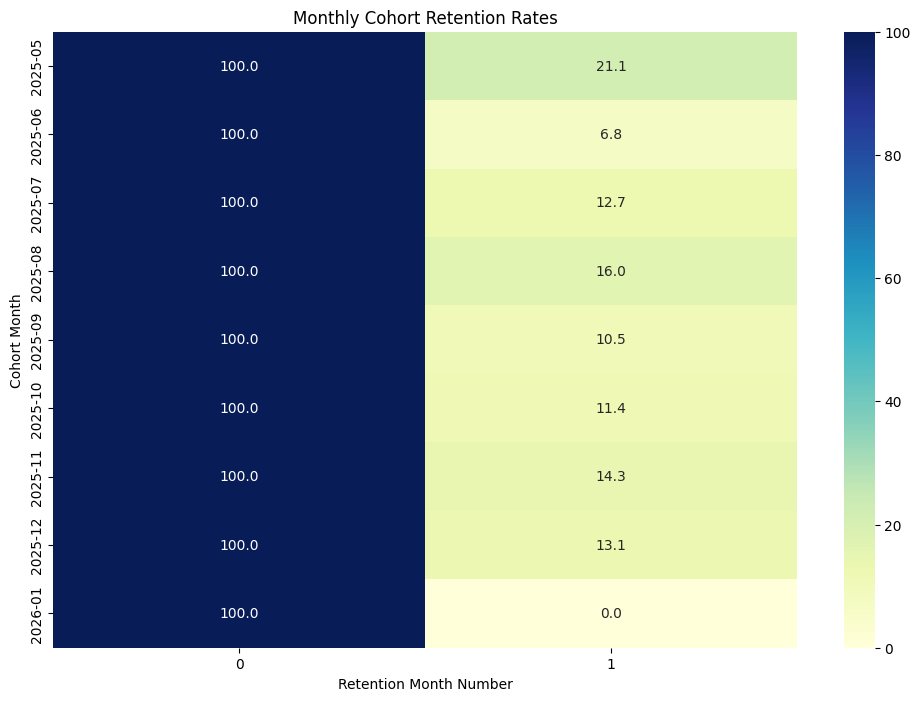

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(retention_pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Monthly Cohort Retention Rates')
plt.xlabel('Retention Month Number')
plt.ylabel('Cohort Month')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta

users = pd.read_csv("/content/users.csv", parse_dates=["signup_date"])
plans = pd.read_csv("/content/plans.csv")
subscriptions = pd.read_csv("/content/subscriptions.csv",
                            parse_dates=["start_date", "end_date", "cancel_date"])
payments = pd.read_csv("/content/payments.csv", parse_dates=["payment_date"])
usage = pd.read_csv("/content/usage_daily.csv")
usage['usage_date'] = pd.to_datetime(usage['usage_date'], format='%d-%m-%Y')

users.drop_duplicates(subset=["user_id"], inplace=True)
subscriptions.drop_duplicates(inplace=True)
payments.drop_duplicates(inplace=True)
users["city_tier"] = users["city_tier"].fillna("unknown")
usage.fillna(0, inplace=True)

as_of_date = pd.to_datetime(usage["usage_date"].max())
users["tenure_days"] = (as_of_date - users["signup_date"]).dt.days
paid_payments = payments[payments["payment_status"] == "success"]
lifetime_paid = paid_payments.groupby("user_id").size().reset_index(name="lifetime_paid_months")
last_active = usage.groupby("user_id")["usage_date"].max().reset_index()
last_active.rename(columns={"usage_date": "last_active_date"}, inplace=True)

recent_4w = usage[usage["usage_date"] >= as_of_date - timedelta(weeks=4)]
engagement = recent_4w.groupby("user_id")["minutes_used"].sum().reset_index()

q1 = engagement["minutes_used"].quantile(0.33)
q2 = engagement["minutes_used"].quantile(0.66)

def engagement_band(x):
    if x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    else:
        return "high"

engagement["engagement_band"] = engagement["minutes_used"].apply(engagement_band)

dim_users = users.merge(lifetime_paid, on="user_id", how="left") \
                 .merge(last_active, on="user_id", how="left") \
                 .merge(engagement[["user_id", "engagement_band"]], on="user_id", how="left")

dim_users.fillna({"lifetime_paid_months":0, "engagement_band":"low"}, inplace=True)

usage["week_start"] = usage["usage_date"] - pd.to_timedelta(usage["usage_date"].dt.weekday, unit='d')

weekly_usage = usage.groupby(["user_id", "week_start"]).agg(
    active_days_week=("usage_date", "nunique"),
    total_minutes_week=("minutes_used", "sum"),
    sessions_week=("sessions_count", "sum")
).reset_index()

weekly_payments = payments.groupby(["user_id",
                                    payments["payment_date"].dt.to_period("W").apply(lambda r: r.start_time)]
                                   ).agg(
    payment_attempts_week=("payment_status", "count"),
    payment_failures_week=("payment_status", lambda x: (x=="failed").sum())
).reset_index()

weekly_payments.columns = ["user_id","week_start",
                           "payment_attempts_week","payment_failures_week"]

fact_weekly = weekly_usage.merge(weekly_payments,
                                  on=["user_id","week_start"], how="left")

fact_weekly.fillna(0, inplace=True)

window_start = as_of_date - timedelta(weeks=4)
model_window = fact_weekly[fact_weekly["week_start"] >= window_start]

agg_features = model_window.groupby("user_id").agg(
    active_days_4w=("active_days_week","sum"),
    total_minutes_4w=("total_minutes_week","sum"),
    sessions_4w=("sessions_week","sum"),
    payment_failures_4w=("payment_failures_week","sum")
).reset_index()

last_week = model_window.groupby("user_id").tail(1)
avg_prev = model_window.groupby("user_id")["active_days_week"].mean().reset_index()

trend = last_week.merge(avg_prev, on="user_id")
trend["usage_trend"] = trend["active_days_week_x"] - trend["active_days_week_y"]
trend = trend[["user_id","usage_trend"]]

model_data = agg_features.merge(trend, on="user_id", how="left") \
                         .merge(dim_users, on="user_id", how="left")

model_data["days_since_last_activity"] = (as_of_date - model_data["last_active_date"]).dt.days

future_cutoff = as_of_date + timedelta(days=14)

subscriptions["will_churn_14d"] = np.where(
    (subscriptions["cancel_date"].notna()) &
    (subscriptions["cancel_date"] <= future_cutoff),
    1, 0
)

churn_label = subscriptions.groupby("user_id")["will_churn_14d"].max().reset_index()

model_data = model_data.merge(churn_label, on="user_id", how="left")
model_data["will_churn_14d"] = model_data["will_churn_14d"].fillna(0)
model_data["as_of_date"] = as_of_date

churn_by_city_tier = model_data.groupby('city_tier')['will_churn_14d'].mean().reset_index()
churn_by_city_tier['churn_rate'] = churn_by_city_tier['will_churn_14d'] * 100

churn_by_engagement_band = model_data.groupby('engagement_band')['will_churn_14d'].mean().reset_index()
churn_by_engagement_band['churn_rate'] = churn_by_engagement_band['will_churn_14d'] * 100

print("Churn Rates by City Tier:")
print(churn_by_city_tier)
print("\nChurn Rates by Engagement Band:")
print(churn_by_engagement_band)


Churn Rates by City Tier:
   city_tier  will_churn_14d  churn_rate
0          1        0.178515   17.851501
1          2        0.192810   19.281046
2          3        0.195956   19.595645

Churn Rates by Engagement Band:
  engagement_band  will_churn_14d  churn_rate
0            high        0.009412    0.941176
1             low        0.521212   52.121212
2          medium        0.044848    4.484848


/tmp/ipykernel_1049/210189272.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city_tier', y='churn_rate', data=churn_by_city_tier, palette='viridis')


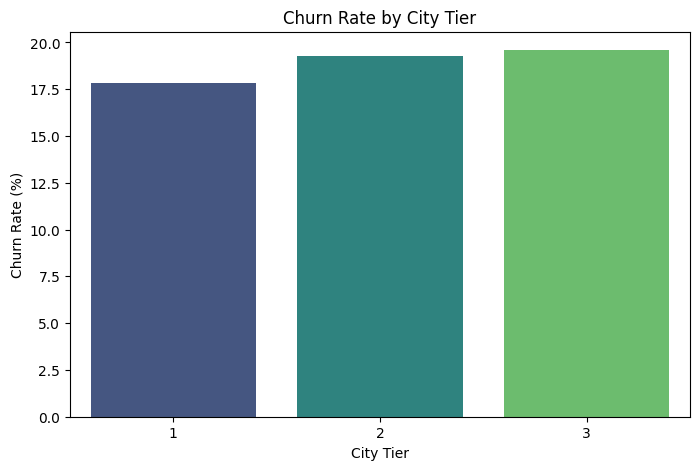

/tmp/ipykernel_1049/210189272.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='engagement_band', y='churn_rate', data=churn_by_engagement_band, palette='magma')


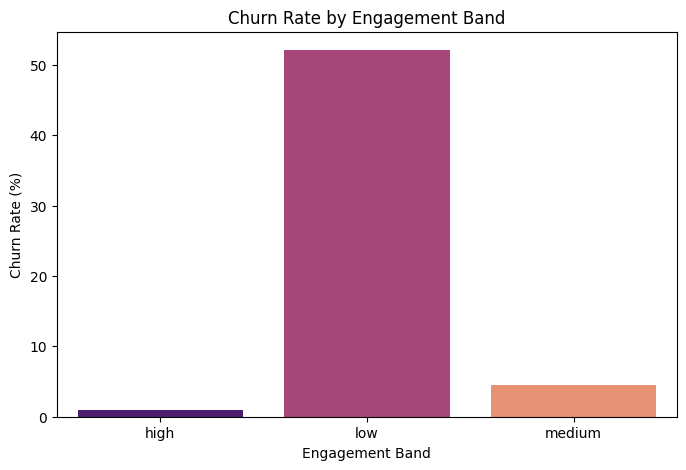

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='city_tier', y='churn_rate', data=churn_by_city_tier, palette='viridis')
plt.title('Churn Rate by City Tier')
plt.xlabel('City Tier')
plt.ylabel('Churn Rate (%)')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='engagement_band', y='churn_rate', data=churn_by_engagement_band, palette='magma')
plt.title('Churn Rate by Engagement Band')
plt.xlabel('Engagement Band')
plt.ylabel('Churn Rate (%)')
plt.show()

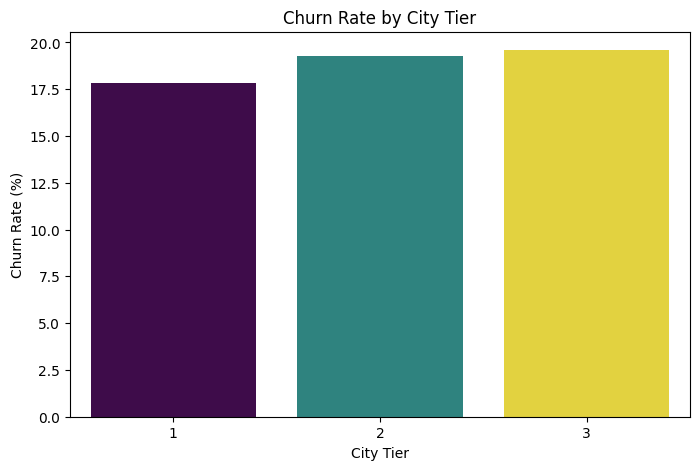

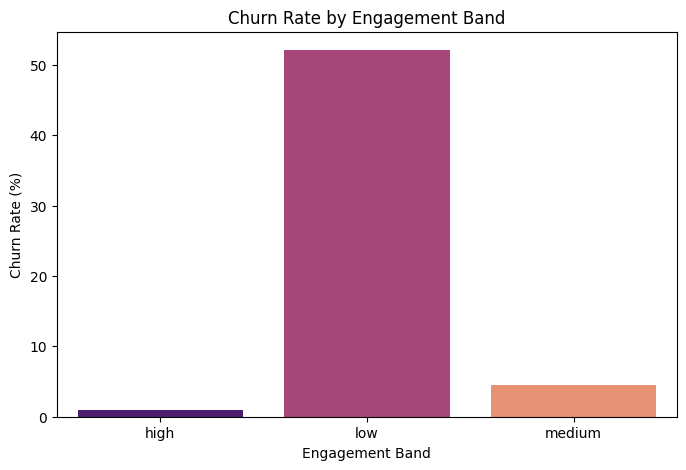

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='city_tier', y='churn_rate', data=churn_by_city_tier, palette='viridis', hue='city_tier', legend=False)
plt.title('Churn Rate by City Tier')
plt.xlabel('City Tier')
plt.ylabel('Churn Rate (%)')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='engagement_band', y='churn_rate', data=churn_by_engagement_band, palette='magma', hue='engagement_band', legend=False)
plt.title('Churn Rate by Engagement Band')
plt.xlabel('Engagement Band')
plt.ylabel('Churn Rate (%)')
plt.show()

In [ ]:
churn_investigation_table = model_data[model_data['will_churn_14d'] == 1]

churn_investigation_table = churn_investigation_table[[
    'user_id', 'signup_date', 'city_tier', 'segment', 'preferred_device',
    'tenure_days', 'lifetime_paid_months', 'engagement_band',
    'active_days_4w', 'total_minutes_4w', 'sessions_4w', 'payment_failures_4w',
    'usage_trend', 'days_since_last_activity', 'will_churn_14d'
]]

print("Churn Investigation Table (first 5 rows):")
print(churn_investigation_table.head())

Churn Investigation Table (first 5 rows):
    user_id signup_date  city_tier  segment preferred_device  tenure_days  \
0   U000001  2025-05-27          1    value           mobile          248   
2   U000003  2025-10-16          1  regular              web          106   
11  U000012  2026-01-04          2    value              web           26   
13  U000014  2025-11-12          3    value           mobile           79   
14  U000015  2025-11-01          2    value              web           90   

    lifetime_paid_months engagement_band  active_days_4w  total_minutes_4w  \
0                    1.0             low              26              0.00   
2                    0.0          medium              26             93.57   
11                   0.0             low              26            169.43   
13                   0.0             low              25             55.69   
14                   0.0             low              25              0.00   

    sessions_4w  payment_f

In [ ]:
avg_plan_price = plans['price'].mean()

num_predicted_churners = len(churn_investigation_table)

estimated_financial_loss = num_predicted_churners * avg_plan_price

print(f"Average Monthly Revenue Per User (AMRPU): ${avg_plan_price:.2f}")
print(f"Number of Predicted Churners: {num_predicted_churners}")
print(f"Estimated Financial Loss Due to Churn: ${estimated_financial_loss:.2f}")

Average Monthly Revenue Per User (AMRPU): $532.33
Number of Predicted Churners: 475
Estimated Financial Loss Due to Churn: $252858.33
